In [13]:
import pandas as pd

df = pd.read_csv("../data/raw/raw_analyst_ratings.csv", encoding="latin1")

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [14]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df = df.dropna(subset=["headline", "publisher", "date"])

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [15]:
df["headline_length"] = df["headline"].apply(len)

df["headline_length"].describe()

count    55987.000000
mean        80.019540
std         56.127357
min         12.000000
25%         42.000000
50%         63.000000
75%         91.000000
max        513.000000
Name: headline_length, dtype: float64

In [16]:
df["publisher"].value_counts().head(10)

publisher
Benzinga Newsdesk      14750
Lisa Levin             12408
ETF Professor           4362
Paul Quintaro           4212
BenzingaâNewsdesk     3177
Benzinga Insights       2332
Vick Meyer              2128
Charles Gross           1790
Hal Lindon              1470
Benzinga_Newsdesk       1239
Name: count, dtype: int64

In [17]:
df["stock"].value_counts().head(10)

stock
A       10
AA      10
AAC     10
AAL     10
AAMC    10
AAME    10
AAN     10
AAOI    10
AAON    10
AAP     10
Name: count, dtype: int64

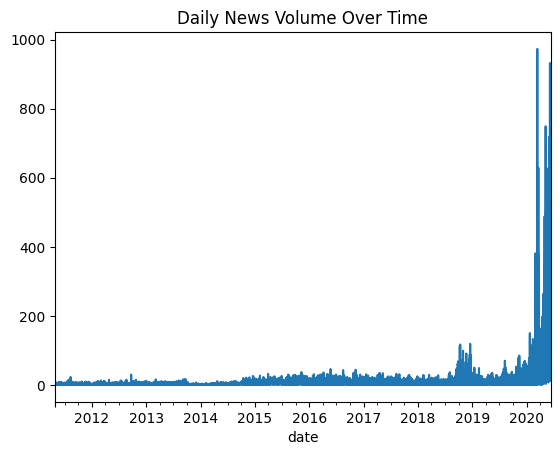

In [18]:
import matplotlib.pyplot as plt

df.set_index("date").resample("D").size().plot()

plt.title("Daily News Volume Over Time")
plt.show()

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=20)

X = tfidf.fit_transform(df["headline"])

tfidf.get_feature_names_out()

array(['52', 'companies', 'eps', 'estimate', 'higher', 'hit', 'lows',
       'maintains', 'market', 'new', 'price', 'q1', 'sales', 'session',
       'shares', 'stocks', 'target', 'trading', 'week', 'yesterday'],
      dtype=object)

c:\news-sentiment-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\news-sentiment-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


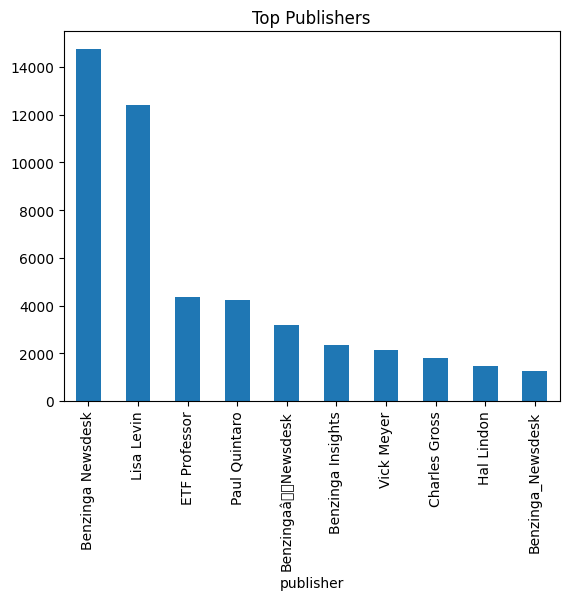

In [20]:
df["publisher"].value_counts().head(10).plot(kind="bar")
plt.title("Top Publishers")
plt.show()

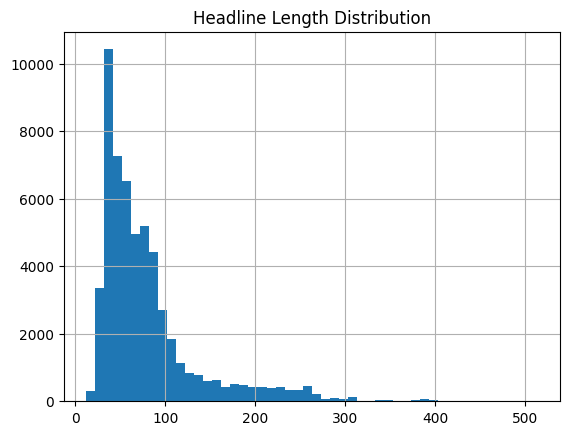

In [21]:
df["headline_length"].hist(bins=50)
plt.title("Headline Length Distribution")
plt.show()

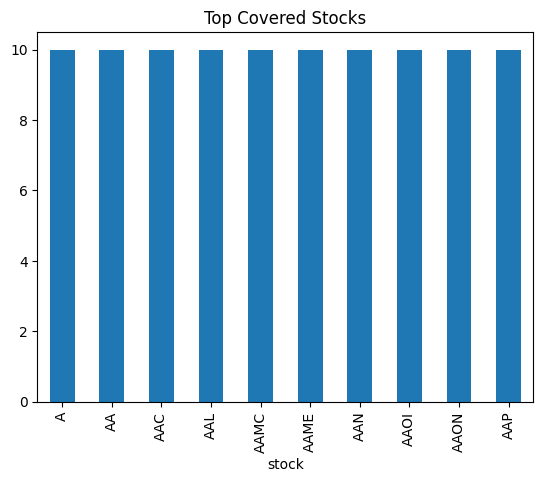

In [22]:
df["stock"].value_counts().head(10).plot(kind="bar")
plt.title("Top Covered Stocks")
plt.show()

In [23]:
df["word_count"] = df["headline"].apply(lambda x: len(str(x).split()))

In [24]:
df["stock"].value_counts().head(15)

stock
A       10
AA      10
AAC     10
AAL     10
AAMC    10
AAME    10
AAN     10
AAOI    10
AAON    10
AAP     10
AAPL    10
AAU     10
AAV     10
AAVL    10
AAWW    10
Name: count, dtype: int64

<Axes: xlabel='stock'>

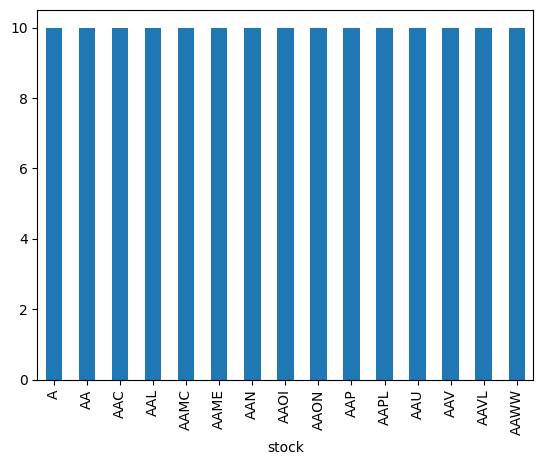

In [25]:
df["stock"].value_counts().head(15).plot(kind="bar")